# Custom Architectures: Plugging In New Encoders and Scorers

The `general` CE package separates *what a `CEModel` does* (embed a center,
embed a set of context candidates, score their similarity) from *how* each of
those steps is implemented. This notebook defines a new encoder and a new
scoring function — different from the shipped `MLPEncoder` /
`CosineTemperatureScorer` — registers them, and trains a `CEModel` built purely
from config, with **no subclassing of `CEModel` itself**.

Prerequisite: `04_general_cemodel_quickstart.ipynb` for the base API.

In [1]:
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt

from conditional_embedding_model.general import (
    Encoder, Scorer, CEModelConfig, EncoderConfig, ScorerConfig,
    build_model, ContrastiveBCELoss, Trainer,
)
from conditional_embedding_model.general.registry import register_encoder, register_scorer, ENCODER_REGISTRY, SCORER_REGISTRY
from conditional_embedding_model.general.examples.toy import make_toy_data

torch.manual_seed(0)
np.random.seed(0)


## 1. The encoder contract

Every encoder subclasses `Encoder` (`general/encoders/base.py`), an
`nn.Module` with one hard requirement: set `self.output_dim` in `__init__` and
implement `forward(self, inputs: dict[str, Tensor]) -> Tensor`, where the
output's last dimension is `output_dim`.

Two details matter for interoperability:

- **`input_spec`** is a class/instance attribute documenting which dict keys
  the encoder consumes (e.g. `{"x": "[B, D] or [B, K, D] float"}`). It's not
  just documentation — `validate_batch`/`self.validate_inputs` uses it to raise
  a readable error instead of a cryptic shape mismatch deep in a `Linear` layer.
- **The same encoder instance-type serves both towers.** `CEModel` calls
  `center_encoder(center_inputs)` on a `[B, ...]`-shaped batch and
  `context_encoder(context_inputs)` on a `[B, K, ...]`-shaped batch. If your
  encoder is built from ops that operate on the last dimension only (e.g.
  `nn.Linear`, `nn.LayerNorm`, elementwise activations), it automatically
  broadcasts over any number of leading batch dims and needs no special-casing
  for "am I the center or the context." That's the same trick `MLPEncoder`
  uses; we'll do the same below but with a residual block instead of a plain
  stack.

In [2]:
@register_encoder("residual_mlp")
class ResidualMLPEncoder(Encoder):
    """A small residual feed-forward encoder: project to hidden width, apply
    N residual (Linear -> LayerNorm -> ReLU) blocks, project to output_dim.
    Operates on the last dim only, so it transparently handles both the
    center's [B, D] and the context's [B, K, D] inputs."""

    input_spec = {"x": "[B, D] or [B, K, D] float"}

    def __init__(self, input_dim, output_dim, hidden_dim=64, n_blocks=2, dropout=0.0, input_key="x"):
        super().__init__()
        self.input_key = input_key
        self.input_spec = {input_key: "[B, D] or [B, K, D] float"}
        self.output_dim = output_dim

        self.in_proj = nn.Linear(input_dim, hidden_dim)
        self.blocks = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.LayerNorm(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            )
            for _ in range(n_blocks)
        ])
        self.out_proj = nn.Linear(hidden_dim, output_dim)

    def forward(self, inputs):
        self.validate_inputs(inputs)
        h = self.in_proj(inputs[self.input_key])
        for block in self.blocks:
            h = h + block(h)
        return self.out_proj(h)


## 2. The scorer contract

A `Scorer` (`general/scoring.py`) implements two methods:

- `forward(v, u)`: `v` is `[B, E]` (center embeddings), `u` is `[B, K, E]`
  (context embeddings for *that same batch's* padded candidate list) →
  returns `[B, K]` (or `[B, K, R]` for multi-relation scorers).
- `all_pairs(v, u)`: `v` is `[B, E]`, `u` is `[M, E]` — a *flat* candidate bank
  shared across the whole batch (no per-row padding) → returns `[B, M]`.

Both are part of the documented contract even though the training loop only
calls `forward`; `all_pairs` is what `CEModel.score_all_pairs` uses for
deployment-style full-bank retrieval (see notebook A, §5), so a scorer that
only implements `forward` silently breaks that path. We define a small
gated-similarity scorer: a learned per-dimension gate on top of cosine
similarity, instead of a single global temperature.

In [3]:
@register_scorer("gated_cosine")
class GatedCosineScorer(Scorer):
    """cosine similarity with a learned per-dimension importance gate:
    sim(v, u) = normalize(v * sigmoid(g)) . normalize(u * sigmoid(g))."""

    def __init__(self, embed_dim, temperature=0.07):
        super().__init__()
        self.gate = nn.Parameter(torch.zeros(embed_dim))
        self.temperature = temperature

    def _gated_normalize(self, x):
        gated = x * torch.sigmoid(self.gate)
        return torch.nn.functional.normalize(gated, dim=-1)

    def forward(self, v, u):
        v = self._gated_normalize(v)
        u = self._gated_normalize(u)
        pred = torch.bmm(v.unsqueeze(1), u.permute(0, 2, 1))
        return pred.squeeze(1) / self.temperature

    def all_pairs(self, v, u):
        v = self._gated_normalize(v)
        u = self._gated_normalize(u)
        return (v @ u.t()) / self.temperature


## 3. Wiring the new components in via config only

`register_encoder`/`register_scorer` add `"residual_mlp"` / `"gated_cosine"` to
the same string registries the built-ins live in
(`ENCODER_REGISTRY`, `SCORER_REGISTRY`). From here on, using them is
indistinguishable from using `"mlp"` or `"cosine_temperature"` — a
`CEModelConfig` naming them, resolved by `build_model`. No `CEModel`
subclass, no edits to `general/core.py`.

In [4]:
print("residual_mlp" in ENCODER_REGISTRY, "gated_cosine" in SCORER_REGISTRY)

obs_dim, K, latent_dim, n_pos, embedding_dim = 32, 16, 4, 2, 8

encoder_params = dict(input_dim=obs_dim, output_dim=embedding_dim, hidden_dim=64, n_blocks=2, dropout=0.0)
config = CEModelConfig(
    embedding_dim=embedding_dim,
    center_encoder=EncoderConfig(name="residual_mlp", params=dict(encoder_params)),
    context_encoder=EncoderConfig(name="residual_mlp", params=dict(encoder_params)),
    scorer=ScorerConfig(name="gated_cosine", params={"embed_dim": embedding_dim, "temperature": 0.07}),
)
model = build_model(config)
model


True True


CEModel(
  (center_encoder): ResidualMLPEncoder(
    (in_proj): Linear(in_features=32, out_features=64, bias=True)
    (blocks): ModuleList(
      (0-1): 2 x Sequential(
        (0): Linear(in_features=64, out_features=64, bias=True)
        (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (2): ReLU()
        (3): Dropout(p=0.0, inplace=False)
      )
    )
    (out_proj): Linear(in_features=64, out_features=8, bias=True)
  )
  (context_encoder): ResidualMLPEncoder(
    (in_proj): Linear(in_features=32, out_features=64, bias=True)
    (blocks): ModuleList(
      (0-1): 2 x Sequential(
        (0): Linear(in_features=64, out_features=64, bias=True)
        (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (2): ReLU()
        (3): Dropout(p=0.0, inplace=False)
      )
    )
    (out_proj): Linear(in_features=64, out_features=8, bias=True)
  )
  (scorer): GatedCosineScorer()
)

## 4. Training on the same synthetic task

We reuse the same planted-affinity toy data generator as notebook A
(`make_toy_data`) purely to demonstrate that swapping architectures via config
doesn't require touching the data pipeline, loss, or trainer at all.

In [5]:
train_data, val_data, W = make_toy_data(
    n_centers=4096, K=K, latent_dim=latent_dim, obs_dim=obs_dim,
    noise=0.1, n_pos=n_pos, seed=0,
)

from torch.utils.data import DataLoader, Dataset as TorchDataset


class _ToyDataset(TorchDataset):
    def __init__(self, data):
        self.center_x = data["center_x"]
        self.context_x = data["context_x"]
        self.label = data["label"]
        self.mask = data["mask"]

    def __len__(self):
        return self.center_x.shape[0]

    def __getitem__(self, i):
        return self.center_x[i], self.context_x[i], self.label[i], self.mask[i]


def _collate(batch):
    center_x = torch.stack([b[0] for b in batch])
    context_x = torch.stack([b[1] for b in batch])
    label = torch.stack([b[2] for b in batch])
    mask = torch.stack([b[3] for b in batch])
    return ({"x": center_x}, {"x": context_x}), label, mask


train_loader = DataLoader(_ToyDataset(train_data), batch_size=256, shuffle=True, collate_fn=_collate)
val_loader = DataLoader(_ToyDataset(val_data), batch_size=256, shuffle=False, collate_fn=_collate)

loss_fn = ContrastiveBCELoss(normalization="valid_pairs")
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
trainer = Trainer(model, loss_fn, optimizer, device="cpu", amp=False)

history = trainer.fit(train_loader, val_loader=val_loader, epochs=15)
print("first epoch train loss:", history["train_loss"][0])
print("final epoch train loss:", history["train_loss"][-1])
assert history["train_loss"][-1] < history["train_loss"][0], "custom encoder/scorer did not train"


first epoch train loss: 0.15243891444779317
final epoch train loss: 0.05350743010149128


val hit@1: 0.9508599508599509
val pr_auc: 0.799790781608644


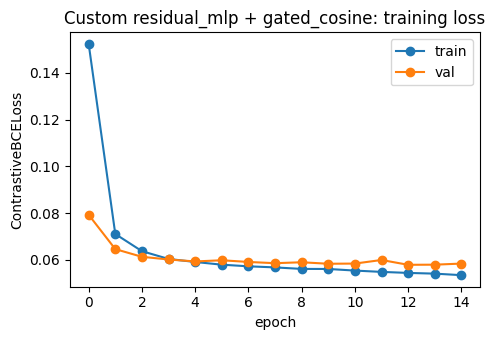

In [6]:
val_metrics = trainer.evaluate(val_loader)
print("val hit@1:", val_metrics["hit_at_k"][1])
print("val pr_auc:", val_metrics["pr_auc"])

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(history["train_loss"], marker="o", label="train")
ax.plot(history["val_loss"], marker="o", label="val")
ax.set_xlabel("epoch")
ax.set_ylabel("ContrastiveBCELoss")
ax.set_title("Custom residual_mlp + gated_cosine: training loss")
ax.legend()
fig.tight_layout()


## 5. Confirming `all_pairs` matches `forward` on the diagonal

Since both `forward` and `all_pairs` are supposed to compute the same
underlying similarity function, scoring a context batch both ways should agree
wherever the two paths overlap: `forward`'s per-row `u[b]` bank is a subset of
what `all_pairs`' shared `u` bank would produce for the same candidates. We
check this on one batch by treating that batch's own (unpadded) candidates as
an `all_pairs` bank and comparing to the `forward` output at the corresponding
positions.

In [7]:
model.eval()
(center_inputs, context_inputs), label, mask = next(iter(val_loader))
with torch.no_grad():
    forward_scores = model(center_inputs, context_inputs)  # [B, K]

    # Use the first row's own candidate bank as a flat `all_pairs` bank.
    row = 0
    valid = mask[row].bool()
    bank_inputs = {"x": context_inputs["x"][row][valid]}
    v = model.embed_center({"x": center_inputs["x"][row : row + 1]})
    u_bank = model.embed_context(bank_inputs) if bank_inputs["x"].dim() == 3 else model.context_encoder(bank_inputs)
    all_pairs_scores = model.scorer.all_pairs(v, u_bank)

diff = (forward_scores[row][valid] - all_pairs_scores[0]).abs().max().item()
print(f"max |forward - all_pairs| on row {row}'s valid candidates: {diff:.3e}")
assert diff < 1e-5, "forward and all_pairs disagree on the same underlying similarity"


max |forward - all_pairs| on row 0's valid candidates: 1.907e-06


## Summary

- A custom encoder needs only: subclass `Encoder`, set `self.output_dim`, take
  `dict[str, Tensor]` in `forward`, and operate on the last dimension so it
  transparently serves both the center (`[B, D]`) and context (`[B, K, D]`)
  towers.
- A custom scorer needs only: subclass `Scorer`, implement both `forward`
  (`[B,E] x [B,K,E] -> [B,K]`) and `all_pairs` (`[B,E] x [M,E] -> [B,M]`).
- `register_encoder("name")` / `register_scorer("name")` make new components
  reachable from `CEModelConfig` by string — no `CEModel` subclass required.

Next: `NN_migrating_existing_checkpoints.ipynb` shows the same `CEModel`
wrapping the paper's original, frozen `CenterEmbeddingResNetv4`/`v5` classes
via a load-time checkpoint shim.